# Task 1: Financial Pipeline, LLM Analysis and Equity Research Brief
Task 1A retrieves dynamic two-year daily NVDA OHLCV, computes indicators with pandas/numpy, retrieves real recent headlines and scores deterministic momentum. Task 1B uses Groq for validated per-headline sentiment and a BUY/HOLD/SELL recommendation over technical relationships. The bonus generates Markdown, styled HTML and a price chart.

Run code cells in order from an updated checkout. Saved outputs should reflect actual execution; no results are prefilled or fabricated. Yahoo/RSS/Groq availability and headline-analysis coverage are reported explicitly. Never paste credentials into notebook source.


In [1]:
import subprocess
import sys
from pathlib import Path

REPOSITORY_URL = "https://github.com/Randimal/CDAZZDEV-MLE-Poshitha-Malagala.git"
cwd = Path.cwd()
repo_root = next(
    (
        p
        for p in (cwd, *cwd.parents)
        if (p / "task1_financial" / "data_pipeline.py").exists()
    ),
    None,
)
if repo_root is None:
    if not REPOSITORY_URL.startswith("https://github.com/"):
        raise ValueError(
            "Set REPOSITORY_URL to your public GitHub repository URL and rerun."
        )
    repo_root = cwd / "CDAZZDEV-MLE-Poshitha-Malagala"
    if not repo_root.exists():
        subprocess.run(
            ["git", "clone", "--", REPOSITORY_URL, str(repo_root)], check=True
        )
    if not (repo_root / "task1_financial" / "data_pipeline.py").exists():
        raise ValueError("Checkout does not contain the Task 1 implementation.")
subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(repo_root / "requirements.txt"),
    ],
    check=True,
)
sys.path.insert(0, str(repo_root))

## Configuration and daily adjusted prices
NVDA, a dynamic 2y period and ten requested headlines are configurable below. Production news uses yfinance first and the existing recent RSS fallback for shortfalls, with deduplication and source-selection logs. Metadata/news failures degrade gracefully; essential price failures are domain errors.


In [2]:
from dataclasses import asdict

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from shared.config import PipelineConfig
from shared.logging_utils import configure_logging
from task1_financial.data_pipeline import run_pipeline
from task1_financial.models import PipelineError

configure_logging()
config = PipelineConfig(ticker="NVDA", period="2y", news_count=10)
result = None
try:
    result = run_pipeline(config)
except PipelineError as exc:
    print(f"Pipeline unavailable: {exc}. Retry when data/network is available.")

In [3]:
if result is not None:
    print("Recent daily OHLCV")
    display(result.data[["Open", "High", "Low", "Close", "Volume"]].tail())
    indicators = [
        "SMA_50",
        "SMA_200",
        "RSI",
        "MACD",
        "MACD_signal",
        "MACD_histogram",
        "BB_middle",
        "BB_upper",
        "BB_lower",
    ]
    print("Latest technical indicators")
    display(result.data[indicators].tail(1).T)

Recent daily OHLCV


,Open,High,Low,Close,Volume
Date,,,,,
2026-09-30 00:00:00-04:00,229.270004,232.369995,228.169998,228.380005,121732200.0
2026-10-01 00:00:00-04:00,229.979996,232.289993,228.160004,230.860001,98591400.0
2026-10-02 00:00:00-04:00,236.059998,237.880005,233.600006,233.949997,135167800.0
2026-10-05 00:00:00-04:00,236.089996,240.100006,235.149994,238.899994,127171500.0
2026-10-06 00:00:00-04:00,242.100006,243.369995,238.929993,239.240005,100868800.0


Latest technical indicators


Date,2026-10-06 00:00:00-04:00
SMA_50,219.623901
SMA_200,201.030556
RSI,67.271905
MACD,4.734877
MACD_signal,3.362184
MACD_histogram,1.372694
BB_middle,224.876000
BB_upper,240.228213
BB_lower,209.523788


In [4]:
if result is not None:
    print(f"{len(result.news)} usable recent headlines (requested {config.news_count})")
    display(
        pd.DataFrame(
            [asdict(item) for item in result.news],
            columns=["title", "publisher", "published_at", "url"],
        )
    )
    if len(result.news) < config.news_count:
        print(
            "Yahoo and the RSS fallback supplied fewer usable headlines; no headlines were fabricated."
        )

10 usable recent headlines (requested 10)


,title,publisher,published_at,url
0,NVIDIA Corporation $NVDA Stock Sold by William...,MarketBeat,2026-10-07T07:43:31+00:00,https://news.google.com/rss/articles/CBMi1AFBV...
1,NVIDIA Corporation $NVDA Stock Holdings Reduce...,MarketBeat,2026-10-07T07:43:30+00:00,https://news.google.com/rss/articles/CBMizAFBV...
2,NVIDIA Corporation $NVDA Stock Acquired by Eme...,MarketBeat,2026-10-07T07:43:29+00:00,https://news.google.com/rss/articles/CBMizwFBV...
3,NVIDIA Corporation $NVDA Stock Purchased by Av...,MarketBeat,2026-10-07T07:06:56+00:00,https://news.google.com/rss/articles/CBMi1wFBV...
4,NVIDIA (NVDA) vs. Apple (AAPL): Which Stock Wi...,Yahoo Finance,2026-10-07T05:19:51+00:00,https://news.google.com/rss/articles/CBMilAFBV...
5,"Why NVDA, AMD, CRWD Stocks Surged To 52-Week H...",Stocktwits,2026-10-07T04:19:00+00:00,https://news.google.com/rss/articles/CBMiugFBV...
6,Nvidia Stock Price Target Splits Crypto Punter...,TradingView,2026-10-07T03:14:00+00:00,https://news.google.com/rss/articles/CBMi8gFBV...
7,SpaceX Stock Drops After Hours as Elon Musk-le...,Yahoo Finance,2026-10-07T01:49:00+00:00,https://news.google.com/rss/articles/CBMimgFBV...
8,SpaceX seeks to raise $40 bln to buy Nvidia ch...,Yahoo Finance,2026-10-06T23:57:11+00:00,https://news.google.com/rss/articles/CBMikwFBV...
9,Is Nvidia’s (NVDA) Free Cash Flow Keeping Pace...,Yahoo Finance,2026-10-06T23:39:04+00:00,https://news.google.com/rss/articles/CBMilgFBV...


In [5]:
if result is not None:
    print("Summary dictionary")
    display(result.summary)
    print("Momentum evidence")
    display(asdict(result.momentum))

Summary dictionary


{'ticker': 'NVDA',
 'current_price': 239.24000549316406,
 '52_week_high': 243.3699951171875,
 '52_week_low': 163.89537828689438,
 'pe_ratio': 30.24526,
 'ytd_return_pct': 28.578997911255843,
 'momentum_signal': 'BULLISH'}

Momentum evidence


{'signal': 'BULLISH',
 'score': 5,
 'reasons': ['Close above SMA_50 (+1)',
  'SMA_50 above SMA_200 (+1)',
  'RSI above RSI midpoint (+1)',
  'MACD above MACD_signal (+1)',
  'Close above BB_middle (+1)']}

In [6]:
if result is not None:
    data = result.data
    bands = data.dropna(subset=["BB_upper", "BB_middle", "BB_lower"])
    checks = {
        "at_least_200_observations": len(data) >= 200,
        "latest_SMA200_defined": pd.notna(data["SMA_200"].iloc[-1]),
        "RSI_in_range": bool(data["RSI"].dropna().between(0, 100).all()),
        "bands_ordered": bool(
            (
                (bands.BB_upper >= bands.BB_middle)
                & (bands.BB_middle >= bands.BB_lower)
            ).all()
        ),
        "valid_momentum": result.momentum.signal in {"BULLISH", "BEARISH", "NEUTRAL"},
    }
    display(checks)
    assert all(checks.values()), "Sanity check failed"
    print(
        f"Requested {config.period}; received {data.index.min()} through {data.index.max()}"
    )

{'at_least_200_observations': True,
 'latest_SMA200_defined': True,
 'RSI_in_range': True,
 'bands_ordered': True,
 'valid_momentum': True}

Requested 2y; received 2024-10-07 00:00:00-04:00 through 2026-10-06 00:00:00-04:00


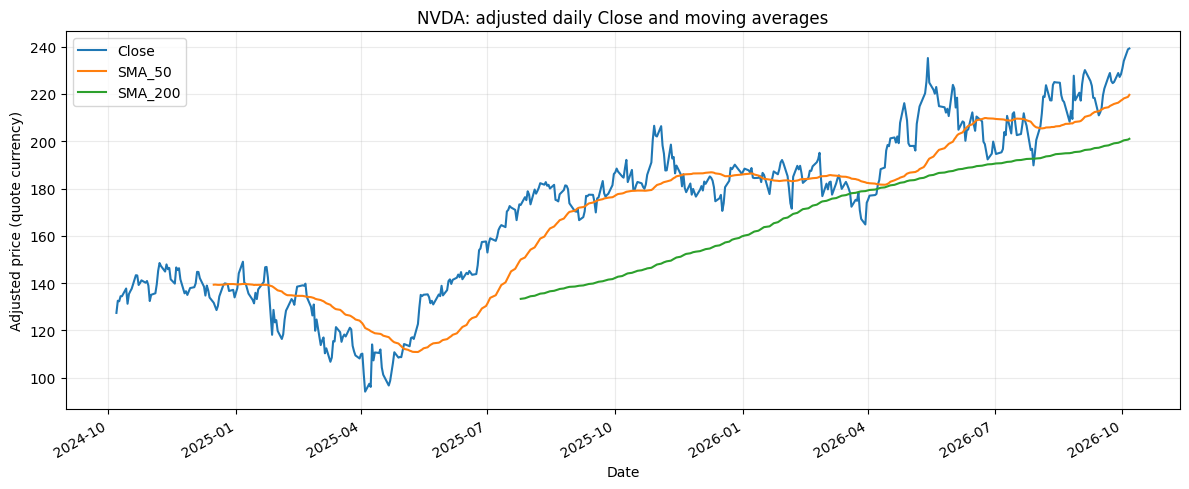

In [7]:
if result is not None:
    fig, ax = plt.subplots(figsize=(12, 5))
    result.data[["Close", "SMA_50", "SMA_200"]].plot(ax=ax)
    ax.set(
        title=f"{result.ticker}: adjusted daily Close and moving averages",
        xlabel="Date",
        ylabel="Adjusted price (quote currency)",
    )
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

## Task 1B: Groq sentiment and recommendation
These cells analyze EVERY retrieved headline (no three-headline subset) and make a bounded validated recommendation request. Use a Groq model supporting JSON object mode. Load GROQ_API_KEY/GROQ_MODEL from environment variables or Colab Secrets, granting notebook access; hidden key input is also supported. Never print settings or paste keys into source.

One model response per headline is validated; transient provider failures may incur bounded transport retries/backoff. Failed headline analyses are counted, never treated as neutral. Aggregate = sum(polarity * confidence) / successful_count; low-confidence predictions reduce its magnitude. No successes means unavailable; a failed recommendation never implies HOLD.


In [8]:
import getpass
import os

from task1_financial.llm import GroqClient, LLMConfigurationError
from task1_financial.recommendation import get_recommendation
from task1_financial.sentiment import analyze_headlines


def load_groq_settings():
    for name in ("GROQ_API_KEY", "GROQ_MODEL"):
        if not os.environ.get(name, "").strip():
            try:
                from google.colab import userdata

                value = userdata.get(name)
                if value:
                    os.environ[name] = value.strip()
            except Exception:
                pass  # Colab absent, secret absent, or permission not granted.
    if not os.environ.get("GROQ_API_KEY", "").strip():
        os.environ["GROQ_API_KEY"] = getpass.getpass("Groq API key (hidden): ").strip()
    if not os.environ.get("GROQ_MODEL", "").strip():
        os.environ["GROQ_MODEL"] = input("Groq JSON-capable model identifier: ").strip()


load_groq_settings()
groq_client = None
try:
    groq_client = GroqClient()
    print("Groq client configured. Credentials are not displayed.")
except LLMConfigurationError:
    print("Set GROQ_API_KEY and GROQ_MODEL, then rerun this cell.")
except Exception:
    print(
        "Groq client initialization failed; check configuration without sharing secrets."
    )

Groq client configured. Credentials are not displayed.


In [9]:
sentiment_batch = None
if result is not None and groq_client is not None:
    sentiment_batch = analyze_headlines(result.ticker, result.news, groq_client)
    display(
        pd.DataFrame(
            [item.model_dump() for item in sentiment_batch.results],
            columns=["headline", "sentiment", "confidence", "brief_reason"],
        )
    )
    print("Aggregate sentiment (successful responses only)")
    display(sentiment_batch.aggregate.model_dump())
    coverage = {
        "requested_headlines": config.news_count,
        "real_headlines_retrieved": len(result.news),
        "successful_headline_analyses": sentiment_batch.aggregate.successful_count,
        "failed_headline_analyses": sentiment_batch.aggregate.failed_count,
    }
    display(coverage)
    if sentiment_batch.aggregate.successful_count >= 10:
        print("At least ten real headlines have validated sentiment results.")
    else:
        print(
            "Ten successful analyses are not yet demonstrated. Inspect shortfalls/failures and rerun after availability/quota recovers."
        )
else:
    print("Fetch valid Task 1A data and configure Groq before sentiment analysis.")

,headline,sentiment,confidence,brief_reason
0,NVIDIA Corporation $NVDA Stock Sold by William...,negative,0.62,The headline reports that William Blair Invest...
1,NVIDIA Corporation $NVDA Stock Holdings Reduce...,negative,0.70,A major investor cutting its position suggests...
2,NVIDIA Corporation $NVDA Stock Acquired by Eme...,positive,0.70,Institutional purchase signals confidence in t...
3,NVIDIA Corporation $NVDA Stock Purchased by Av...,positive,0.70,The announcement of a purchase by an investmen...
4,NVIDIA (NVDA) vs. Apple (AAPL): Which Stock Wi...,neutral,0.78,The headline asks a comparative question witho...
5,"Why NVDA, AMD, CRWD Stocks Surged To 52-Week H...",positive,0.90,The headline states NVDA stocks surged to 52‑w...
6,Nvidia Stock Price Target Splits Crypto Punter...,neutral,0.60,The headline highlights divergent price target...
7,SpaceX Stock Drops After Hours as Elon Musk-le...,neutral,0.60,The piece centers on SpaceX's stock fall; whil...
8,SpaceX seeks to raise $40 bln to buy Nvidia ch...,positive,0.85,The headline indicates a large purchase order ...
9,Is Nvidia’s (NVDA) Free Cash Flow Keeping Pace...,neutral,0.80,The headline poses a question about cash flow ...


Aggregate sentiment (successful responses only)


{'overall_score': 0.183,
 'positive_count': 4,
 'negative_count': 2,
 'neutral_count': 4,
 'successful_count': 10,
 'failed_count': 0,
 'overall_label': 'neutral'}

{'requested_headlines': 10,
 'real_headlines_retrieved': 10,
 'successful_headline_analyses': 10,
 'failed_headline_analyses': 0}

At least ten real headlines have validated sentiment results.


### Derived technical relationships
The production helper describes signed price distances from SMA50/SMA200, moving-average order, trend structure, RSI regime, MACD confirmation/conflict, histogram sign, Bollinger location and deterministic momentum. These are relationships among computed observations, not historical crossover detection or predictions. Missing values remain null. The same compact facts enter the recommendation payload.


In [10]:
from task1_financial.recommendation import recommendation_payload

technical_facts = None
if result is not None:
    aggregate = sentiment_batch.aggregate if sentiment_batch is not None else None
    technical_facts = recommendation_payload(result, aggregate)["technical_facts"]
    display(technical_facts)
else:
    print("Fetch usable price data before deriving technical relationships.")

{'price_vs_sma50_pct': 8.931680326562796,
 'price_vs_sma200_pct': 19.006786846645674,
 'sma50_vs_sma200': 'above',
 'trend_structure': 'bullish',
 'rsi_regime': 'strong',
 'macd_vs_signal': 'above',
 'macd_histogram_sign': 'positive',
 'bollinger_location': 'upper_half',
 'deterministic_momentum': 'BULLISH'}

### Validated technical recommendation
The compact payload contains nine latest indicators, adjusted current price, derived technical relationships, deterministic momentum and aggregate sentiment coverage. No historical OHLCV table is sent. Missing numeric values become JSON null. The prompt requires confirmation AND contradiction: a bullish price/average structure and positive MACD may agree, while overbought RSI or an upper-band stretch may reduce conviction. The model must synthesize evidence, not list values or invent crossings.

Pydantic requires BUY/HOLD/SELL and 3–5 complete sentences. Response validation is bounded; transient transport backoff is separate. An unavailable recommendation remains explicitly unavailable.


In [11]:
# Refresh updated modules without repeating price/news/sentiment calls.
import importlib
import task1_financial.llm as recommendation_transport
import task1_financial.prompts as recommendation_prompts
import task1_financial.recommendation as recommendation_module

importlib.reload(recommendation_transport)
importlib.reload(recommendation_prompts)
importlib.reload(recommendation_module)
get_recommendation = recommendation_module.get_recommendation
if groq_client is not None:
    groq_client = recommendation_transport.GroqClient(
        max_completion_tokens=groq_client.max_completion_tokens
    )

recommendation = None
if result is not None and groq_client is not None:
    aggregate = sentiment_batch.aggregate if sentiment_batch is not None else None
    recommendation = get_recommendation(result, groq_client, aggregate)
    if recommendation is not None:
        display(recommendation.model_dump())
        print(
            "Accepted TechnicalRecommendation: signal enum and 3–5 sentence structure validated."
        )
    else:
        print(
            "No valid LLM recommendation after bounded retries; no signal substituted."
        )
else:
    print("Valid Task 1A data and Groq configuration are required.")

{'signal': 'BUY',
 'reasoning': 'The price is well above both the 50‑day and 200‑day moving averages, confirming a strong bullish trend. MACD is above its signal line and the histogram is positive, adding momentum confirmation. RSI is in the strong range (67) but below the overbought threshold, while the price sits just below the upper Bollinger band, indicating a short‑term overextension risk. News sentiment is neutral, providing no additional directional bias. Considering the dominant bullish technical picture with modest caution, a buy signal is appropriate.'}

Accepted TechnicalRecommendation: signal enum and 3–5 sentence structure validated.


### Structured-output rejection demo (offline)
Intentionally submit an invalid signal to the actual production TechnicalRecommendation model. The reasoning is test text, not market analysis. No LLM/API request is made; the caught ValidationError shows that an invalid enum cannot enter business logic.


In [12]:
from pydantic import ValidationError

from task1_financial.llm_models import TechnicalRecommendation

try:
    TechnicalRecommendation.model_validate(
        {
            "signal": "BULLISH",  # Invalid: only BUY / HOLD / SELL are accepted.
            "reasoning": "This is a schema test. No market facts are asserted. It makes no trading recommendation.",
        }
    )
except ValidationError as exc:
    print("Invalid structured output rejected by the production Pydantic model:")
    display(
        pd.DataFrame(
            [
                {
                    "field": ".".join(str(part) for part in issue["loc"]),
                    "error": issue["msg"],
                }
                for issue in exc.errors(include_input=False)
            ]
        )
    )
else:
    raise AssertionError("Invalid signal unexpectedly accepted")

Invalid structured output rejected by the production Pydantic model:


,field,error
0,signal,"Input should be 'BUY', 'HOLD' or 'SELL'"


### Invalid-ticker robustness demo (real provider boundary)
Run the actual production pipeline for NOTAREALTICKER123, with news disabled because prices must succeed first. Catch its domain error without overwriting the valid NVDA result. A provider outage can produce the same controlled failure, so the output names the exception type rather than claiming a network failure proves a ticker is invalid.


In [13]:
INVALID_TICKER = "NOTAREALTICKER123"
try:
    run_pipeline(PipelineConfig(ticker=INVALID_TICKER, period="2y"), include_news=False)
except PipelineError as exc:
    print(
        f"Controlled failure ({type(exc).__name__}): {INVALID_TICKER} has no usable history or the provider is unavailable. The notebook can continue."
    )
else:
    print(
        "Unexpected provider history for the demonstration ticker; inspect it before using it. The NVDA result is unchanged."
    )

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: NOTAREALTICKER123"}}}
ERROR:yfinance:$NOTAREALTICKER123: possibly delisted; no price data found  (period=2y) (Yahoo error = "No data found, symbol may be delisted")


Controlled failure (DataFetchError): NOTAREALTICKER123 has no usable history or the provider is unavailable. The notebook can continue.


### Bonus: equity research brief
Create Markdown, print-styled HTML and a Close/SMA50/SMA200 PNG chart under task1_financial/outputs/. The HTML is designed as a compact A4 brief; browser print scaling and fonts can affect pagination. It uses real pipeline data and marks unavailable analysis explicitly. Reports and notebook output should be reviewed before submission; no example artifacts are fabricated.

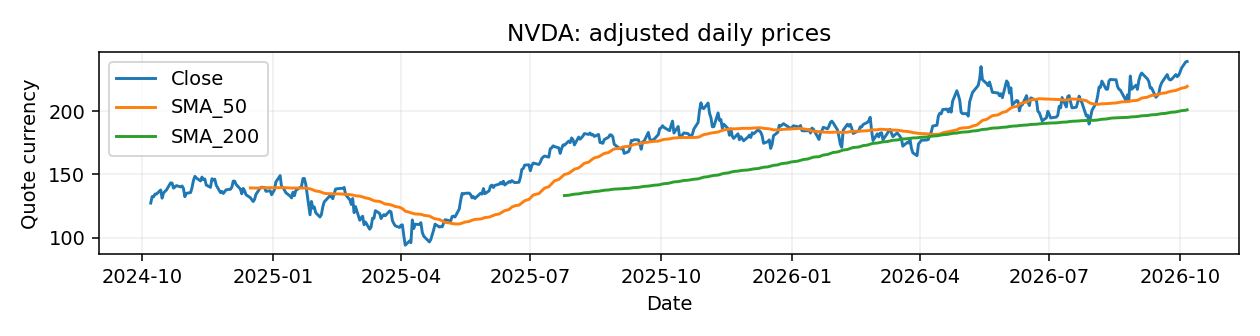

# NVDA — Equity Research Brief

Price observation: 2026-10-06T00:00:00-04:00; generated UTC: 20261007T092021164071Z.

## Company Snapshot

Ticker: NVDA \| Latest adjusted close: 239\.24 \| 52\-week high/low: 243\.37 / 163\.90 \| Trailing PE: 30\.25 \| YTD: 28\.58%

## Technical Outlook

Deterministic momentum: BULLISH \(score \+5/5\)\. Close above SMA\_50 \(\+1\) SMA\_50 above SMA\_200 \(\+1\) RSI above RSI midpoint \(\+1\) MACD above MACD\_signal \(\+1\) Close above BB\_middle \(\+1\)

![Adjusted Close, SMA50 and SMA200](NVDA_20261007T092021164071Z.png)

## News Sentiment

Aggregate: neutral; score: 0\.18\. Positive/negative/neutral: 4/2/4\. Successful: 10; failed: 0\.

- NVIDIA Corporation $NVDA Stock Sold by William Blair Investment Management LLC

- NVIDIA Corporation $NVDA Stock Holdings Reduced by Korea Investment CORP

- NVIDIA Corporation $NVDA Stock Acquired by Emerald Investment Advisers LLC

## Recommendation

BUY: The price is well above both the 50‑day and 200‑day moving averages, confirming a strong bullish trend\. MACD is above its signal line and the histogram is positive, adding momentum confirmation\. RSI is in the strong range \(67\) but below the overbought threshold, while the price sits just below the upper Bollinger band, indicating a short‑term overextension risk\. News sentiment is neutral, providing no additional directional bias\. Considering the dominant bullish technical picture with modest caution, a buy signal is appropriate\.

## Risk Disclaimer

Educational research only; not personalized investment advice\. Adjusted daily prices may be delayed or revised\. News coverage is incomplete; LLM reasoning can be wrong and confidence is not calibrated\. Review original sources and independent evidence before making decisions\.


task1_financial/outputs/NVDA_20261007T092021164071Z.md


/content/CDAZZDEV-MLE-Poshitha-Malagala/task1_financial/outputs/NVDA_20261007T092021164071Z.md

task1_financial/outputs/NVDA_20261007T092021164071Z.html


/content/CDAZZDEV-MLE-Poshitha-Malagala/task1_financial/outputs/NVDA_20261007T092021164071Z.html

task1_financial/outputs/NVDA_20261007T092021164071Z.png


/content/CDAZZDEV-MLE-Poshitha-Malagala/task1_financial/outputs/NVDA_20261007T092021164071Z.png

In [14]:
from pathlib import Path

from IPython.display import FileLink, Image, Markdown

from task1_financial.report import generate_report

report_artifacts = None
if result is not None:
    aggregate = sentiment_batch.aggregate if sentiment_batch is not None else None
    report_artifacts = generate_report(
        result,
        aggregate,
        recommendation,
        Path(repo_root) / "task1_financial" / "outputs",
    )
    display(Image(filename=str(report_artifacts.chart)))
    display(Markdown(report_artifacts.markdown.read_text(encoding="utf-8")))
    for artifact in (
        report_artifacts.markdown,
        report_artifacts.html,
        report_artifacts.chart,
    ):
        print(artifact.relative_to(repo_root))
        display(FileLink(str(artifact)))
else:
    print("No valid price data: no research report generated.")

## Interpretation, limitations and financial-risk disclaimer
Current price is the latest adjusted daily close, not an intraday quote. Yahoo auto_adjust=True adjusts OHLC for corporate actions; adjusted returns/extrema can differ from nominal-price fields. YTD uses the last valid close before January 1; missing baseline yields null. Bands use population standard deviation (ddof=0). RSI has an arithmetic Wilder seed and alpha=1/14 smoothing; missing prices reset state. Momentum and RSI regimes are documented heuristics, not calibrated forecasts.

News/search matches require source/relevance review, and ten usable headlines or successful LLM responses cannot be guaranteed during outages/quota limits. Confidence reduces aggregate magnitude but is not a calibrated probability. Pydantic proves structure and sentence count, not the truth or economic quality of LLM reasoning. None of these daily technical inputs establishes balance-sheet health.

Educational research only; not personalized investment advice. Prices/news can be incomplete, delayed or revised and LLM reasoning can be wrong. Review original sources and independent evidence before making decisions. Download the HTML with its PNG chart to preserve the relative image reference and check browser print layout. Reports are generated only from actual retrieved data. Task 2 remains pending; Task 3 has its own notebook.
